# 당뇨 예측 - CatBoost Feature Engineering 실험

- 타겟: `당뇨유병` (0: 없음 / 1: 있음)
- 모델: CatBoost (Optuna 최적 파라미터 고정)
- 데이터: `hn_all_preprocessed_v4.csv` (15~24년 통합)
- Threshold: 0.50 고정
- FE: 미적용
- 목적: **피처 추가·제거 실험으로 성능 변화 확인**
- 검증: Stratified 5-Fold CV

In [13]:
import os
import sys
import warnings

import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from catboost import CatBoostClassifier, Pool
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import StratifiedKFold

warnings.filterwarnings("ignore")
matplotlib.rcParams["font.family"] = "DejaVu Sans"

# ── 경로 설정 (상대 경로) ──────────────────────────────────
CURRENT_DIR = os.path.dirname(os.path.abspath(""))
BASE_DIR = os.path.join(CURRENT_DIR, "..")
DATA_PATH = os.path.join(BASE_DIR, "data", "hn_all_preprocessed_v4.csv")
FEATURES_DIR = os.path.join(BASE_DIR, "features")
NPY_DIR = os.path.join(BASE_DIR, "outputs", "oof")
sys.path.insert(0, FEATURES_DIR)

RANDOM_STATE = 42
THRESHOLD = 0.50

In [14]:
df = pd.read_csv(DATA_PATH)
print(f"로드 완료 | shape: {df.shape}")

로드 완료 | shape: (22102, 31)


In [15]:
# ── 피처 엔지니어링 함수 import ──────────────────────────────

# ── 적용할 피처 선택 (주석 해제 = 적용) ──────────────────────
# df = add_age_bin(df, drop_original=False)                  # 나이_구간
# df = add_age_bin5(df, drop_original=False)                 # 나이_5구간

# 가족력 실험
# df = add_family_sum(df, diabetes=True, hypertension=False, dyslipidemia=False,
#                     drop_original=True) # 가족력_3종_제거 + 가족력_합산
# df = df.drop(columns=[
#     '고혈압가족력_부', '고혈압가족력_모', '고혈압가족력_형제',
#     '고지혈증가족력_부', '고지혈증가족력_모', '고지혈증가족력_형제',]) # 가족력 실험

# BMI 실험
# df = add_bmi_bin(df, korean_standard=True, drop_original=True) # BMI_구간(True: 한국인 기준, False: WHO 기준)
# df = df.drop(columns=[ '키', '체중',]) # BMI 실험

# df = add_alcohol_load(df, drop_original=True)  # 음주_총부하 (필요 시 해제)
# df = add_exercise_total(df, drop_original=False)         # 총운동일수 (필요 시 해제)
# df = add_body_features(df, weight_height_ratio=True, bmi_age_interaction=False, drop_original=True) # 체형 복합 (필요 시 해제)
# df = add_age_family_interaction(df, hypertension=False, diabetes=True)   # 나이×가족력 (필요 시 해제)


print(f"\n피처 엔지니어링 완료 | shape: {df.shape}")

[fe_age_bin5] '나이_구간5' 추가 완료
  분포:
나이_구간5
0    4022
1    3126
2    4040
3    5277
4    5637
  (0: 19~39세 / 1: 40~49세 / 2: 50~59세 / 3: 60~69세 / 4: 70세 이상)
[fe_bmi_bin] 'BMI_구간' 추가 완료 (한국인 기준 (18.5/23/25/30))
  분포:
BMI_구간
0.0     809
1.0    7517
2.0    5004
3.0    6860
4.0    1527
  NaN: 385건 (BMI 결측 → 모델 자체 처리)
[fe_bmi_bin] 원본 'BMI' 컬럼 제거

피처 엔지니어링 완료 | shape: (22102, 32)


## 3. 피처 / 타겟 분리

In [16]:
TARGET = "당뇨유병"
DROP_COLS = ["고혈압유병", "당뇨유병", "이상지질혈증유병"]

data = df.dropna(subset=[TARGET]).copy()
X = data.drop(columns=DROP_COLS)
y = data[TARGET].astype(int)
neg, pos = (y == 0).sum(), (y == 1).sum()
ratio = neg / pos

print(f"샘플 수: {len(y)}  |  정상: {neg}  |  당뇨: {pos}")
print(f"사용 피처 수: {X.shape[1]}")
print(f"피처 목록: {list(X.columns)}")

샘플 수: 22050  |  정상: 15732  |  당뇨: 6318
사용 피처 수: 29
피처 목록: ['성별', '나이', '현재흡연', '걷기일수', '근력운동일수', '고혈압가족력_부', '고혈압가족력_모', '고혈압가족력_형제', '고지혈증가족력_부', '고지혈증가족력_모', '고지혈증가족력_형제', '당뇨가족력_부', '당뇨가족력_모', '당뇨가족력_형제', '키', '체중', '직업_관리전문', '직업_사무', '직업_서비스판매', '직업_농림어업', '직업_기능노무', '직업_주부학생', '직업_무직', '직업_작업미상', '과거음주_현재금주', '음주빈도_enc', '음주량_enc', '나이_구간5', 'BMI_구간']


## 4. Optuna 최적 파라미터 설정

In [17]:
best_params = dict(
    iterations=585,
    learning_rate=0.03417929367057629,
    depth=5,
    l2_leaf_reg=4.210544242744235,
    bagging_temperature=0.35554454697929566,
    random_strength=0.9045504755091893,
    border_count=115,
    loss_function="Logloss",
    eval_metric="AUC",
    class_weights={0: 1.0, 1: ratio},
    early_stopping_rounds=50,
    random_seed=RANDOM_STATE,
    verbose=False,
    allow_writing_files=False,
)
print("파라미터 설정 완료")

파라미터 설정 완료


## 5. Stratified 5-Fold CV

In [18]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
oof_proba = np.zeros(len(y))
fold_scores = []

print("=" * 65)
for fold, (tr_idx, val_idx) in enumerate(skf.split(X, y), 1):
    X_tr, X_val = X.iloc[tr_idx], X.iloc[val_idx]
    y_tr, y_val = y.iloc[tr_idx], y.iloc[val_idx]
    model = CatBoostClassifier(**best_params)
    model.fit(Pool(X_tr, y_tr), eval_set=Pool(X_val, y_val))
    proba = model.predict_proba(X_val)[:, 1]
    oof_proba[val_idx] = proba
    pred = (proba >= THRESHOLD).astype(int)
    cm_f = confusion_matrix(y_val, pred)
    fold_scores.append(
        {
            "fold": fold,
            "auc": roc_auc_score(y_val, proba),
            "f1": f1_score(y_val, pred),
            "recall": recall_score(y_val, pred),
            "precision": precision_score(y_val, pred),
            "fp": int(cm_f[0, 1]),
            "best_iter": model.best_iteration_,
        }
    )
    print(
        f"  Fold {fold} | AUC: {fold_scores[-1]['auc']:.4f} | "
        f"Recall: {fold_scores[-1]['recall']:.4f} | "
        f"F1: {fold_scores[-1]['f1']:.4f} | "
        f"best_iter: {model.best_iteration_}"
    )

scores_df = pd.DataFrame(fold_scores)
print("=" * 65)
print(
    f"  평균   | AUC: {scores_df.auc.mean():.4f}±{scores_df.auc.std():.4f} "
    f"| Recall: {scores_df.recall.mean():.4f}±{scores_df.recall.std():.4f} "
    f"| F1: {scores_df.f1.mean():.4f}±{scores_df.f1.std():.4f}"
)

  Fold 1 | AUC: 0.8033 | Recall: 0.8068 | F1: 0.6015 | best_iter: 370
  Fold 2 | AUC: 0.8074 | Recall: 0.8131 | F1: 0.6023 | best_iter: 309
  Fold 3 | AUC: 0.7945 | Recall: 0.7959 | F1: 0.5919 | best_iter: 336
  Fold 4 | AUC: 0.8091 | Recall: 0.8157 | F1: 0.6031 | best_iter: 351
  Fold 5 | AUC: 0.8162 | Recall: 0.8196 | F1: 0.6071 | best_iter: 461
  평균   | AUC: 0.8061±0.0080 | Recall: 0.8102±0.0093 | F1: 0.6012±0.0056


## 6. OOF proba 저장 (.npy)

In [19]:
os.makedirs(NPY_DIR, exist_ok=True)
npy_path = os.path.join(NPY_DIR, "oof_proba_DM_catboost_v3_fe.npy")
oof_array = np.stack([oof_proba, y.values], axis=1)
np.save(npy_path, oof_array)
print(f"저장 완료 → {npy_path}")
loaded = np.load(npy_path)
print(f"로드 확인: shape={loaded.shape}, 일치={np.allclose(oof_array, loaded)}")

저장 완료 → /Users/Jiyeon/Desktop/final_project/ML/model/../outputs/oof/oof_proba_DM_catboost_v3_fe.npy
로드 확인: shape=(22050, 2), 일치=True


## 7. OOF 성능 & 기준 모델 비교

In [20]:
pred_oof = (oof_proba >= THRESHOLD).astype(int)
cm = confusion_matrix(y, pred_oof)

oof_auc = roc_auc_score(y, oof_proba)
oof_rec = recall_score(y, pred_oof)
oof_prec = precision_score(y, pred_oof)
oof_f1 = f1_score(y, pred_oof)
oof_acc = float((pred_oof == y).mean())

# 기준 모델 (FE 없음, Optuna)
BASE = {"auc": 0.8059, "recall": 0.8148, "precision": 0.4776, "f1": 0.6022, "acc": 0.6916, "fp": 5631, "fn": 1170}

print("=" * 55)
print(f"  {'지표':<12}  {'기준 모델':>12}  {'FE 적용':>10}  변화")
print("=" * 55)
for label, base_v, cur_v in [
    ("AUC-ROC", BASE["auc"], oof_auc),
    ("Recall", BASE["recall"], oof_rec),
    ("Precision", BASE["precision"], oof_prec),
    ("F1-score", BASE["f1"], oof_f1),
    ("Accuracy", BASE["acc"], oof_acc),
]:
    d = cur_v - base_v
    arrow = "▲" if d > 0 else ("▼" if d < 0 else "─")
    print(f"  {label:<12}  {base_v:>12.4f}  {cur_v:>10.4f}  {arrow} {abs(d):.4f}")
print(
    f"  {'FP':<12}  {BASE['fp']:>12}  {cm[0, 1]:>10}  {'▼' if cm[0, 1] < BASE['fp'] else '▲'} {abs(cm[0, 1] - BASE['fp'])}"
)
print(
    f"  {'FN':<12}  {BASE['fn']:>12}  {cm[1, 0]:>10}  {'▼' if cm[1, 0] < BASE['fn'] else '▲'} {abs(cm[1, 0] - BASE['fn'])}"
)
print("=" * 55)
print("\n[분류 리포트]")
print(classification_report(y, pred_oof, target_names=["정상(0)", "당뇨(1)"]))

  지표                   기준 모델       FE 적용  변화
  AUC-ROC             0.8059      0.8061  ▲ 0.0002
  Recall              0.8148      0.8102  ▼ 0.0046
  Precision           0.4776      0.4779  ▲ 0.0003
  F1-score            0.6022      0.6012  ▼ 0.0010
  Accuracy            0.6916      0.6920  ▲ 0.0004
  FP                    5631        5592  ▼ 39
  FN                    1170        1199  ▲ 29

[분류 리포트]
              precision    recall  f1-score   support

       정상(0)       0.89      0.64      0.75     15732
       당뇨(1)       0.48      0.81      0.60      6318

    accuracy                           0.69     22050
   macro avg       0.69      0.73      0.68     22050
weighted avg       0.77      0.69      0.71     22050



## 8. Confusion Matrix

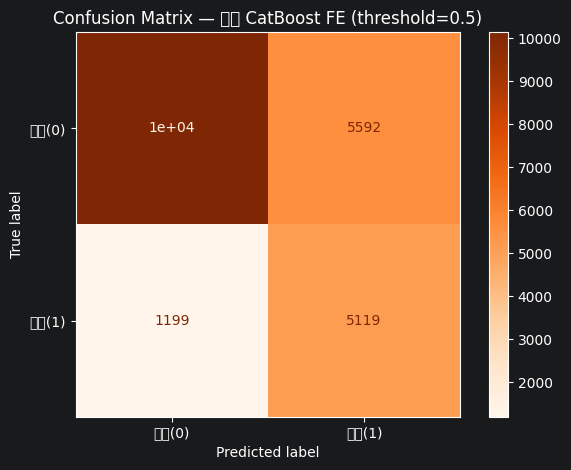

In [21]:
disp = ConfusionMatrixDisplay(cm, display_labels=["정상(0)", "당뇨(1)"])
disp.plot(cmap="Oranges")
plt.title(f"Confusion Matrix — 당뇨 CatBoost FE (threshold={THRESHOLD})")
plt.tight_layout()
plt.show()

## 9. Feature Importance (CatBoost, 5-Fold 평균)

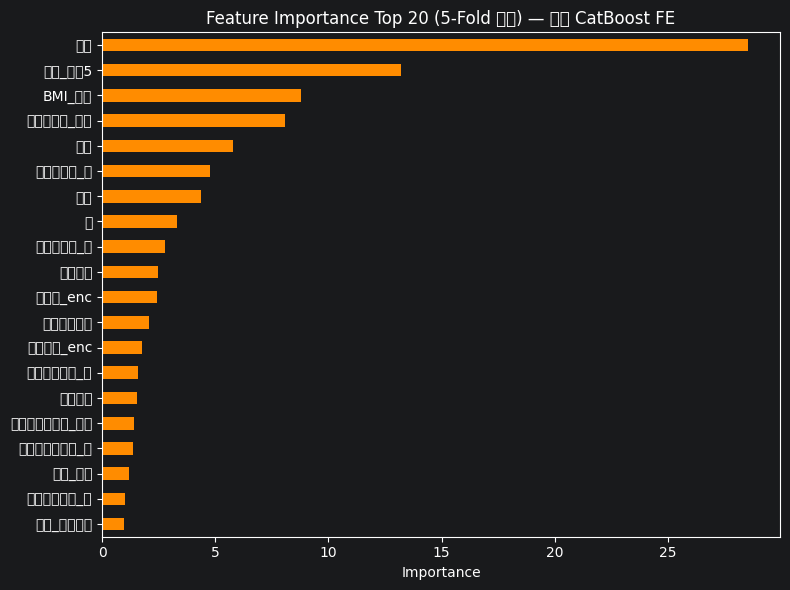

나이            28.522848
나이_구간5        13.213587
BMI_구간         8.798605
당뇨가족력_형제       8.089059
체중             5.766041
당뇨가족력_모        4.758285
성별             4.369326
키              3.318243
당뇨가족력_부        2.758206
걷기일수           2.456136
음주량_enc        2.409804
근력운동일수         2.080719
음주빈도_enc       1.773152
고혈압가족력_모       1.591623
현재흡연           1.539201
고지혈증가족력_형제     1.394237
고지혈증가족력_모      1.353324
직업_무직          1.189521
고혈압가족력_부       0.990893
직업_관리전문        0.982835


In [22]:
fi_list = []
for fold, (tr_idx, val_idx) in enumerate(
    StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE).split(X, y), 1
):
    X_tr, X_val = X.iloc[tr_idx], X.iloc[val_idx]
    y_tr, y_val = y.iloc[tr_idx], y.iloc[val_idx]
    m = CatBoostClassifier(**best_params)
    m.fit(Pool(X_tr, y_tr), eval_set=Pool(X_val, y_val))
    fi_list.append(m.get_feature_importance())

fi = pd.DataFrame(fi_list, columns=X.columns).mean(axis=0)
fi = fi.sort_values(ascending=False)

plt.figure(figsize=(8, 6))
fi.head(20)[::-1].plot(kind="barh", color="darkorange")
plt.title("Feature Importance Top 20 (5-Fold 평균) — 당뇨 CatBoost FE")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()
print(fi.head(20).to_string())

## 10. SHAP 분석 (OOF 전체 기준)

SHAP Fold 1 완료
SHAP Fold 2 완료
SHAP Fold 3 완료
SHAP Fold 4 완료
SHAP Fold 5 완료


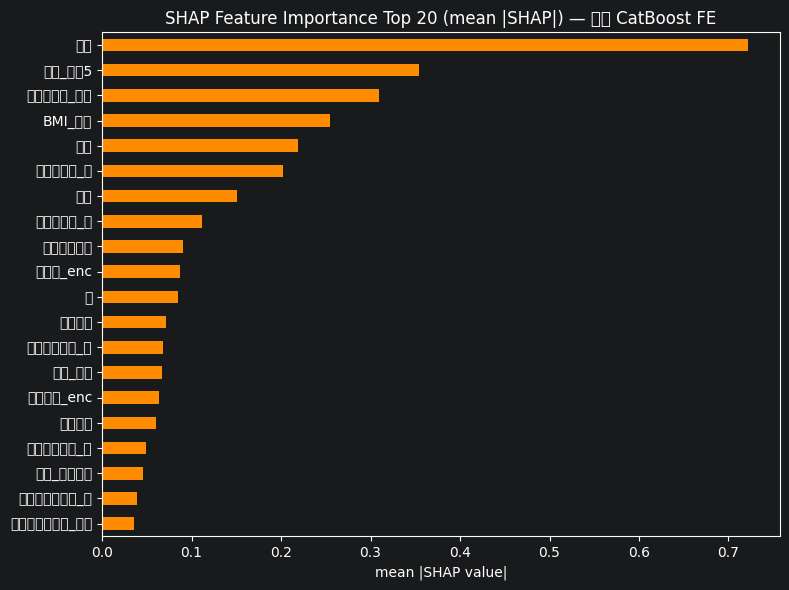

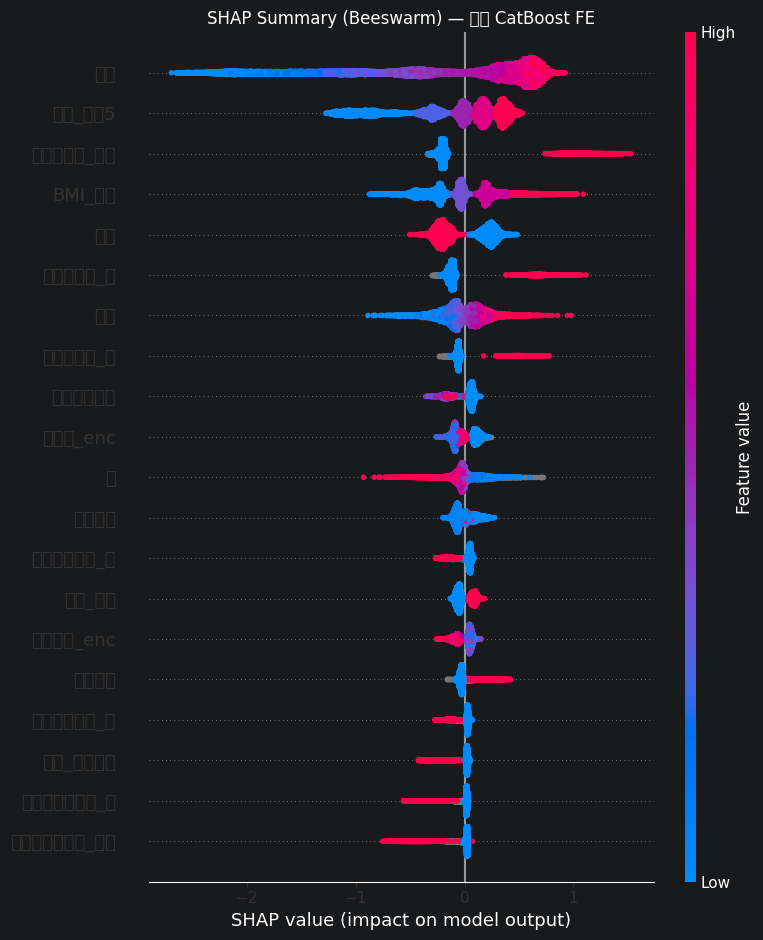

[SHAP Top 15]
   1. 나이: 0.7215
   2. 나이_구간5: 0.3543
   3. 당뇨가족력_형제: 0.3093
   4. BMI_구간: 0.2550
   5. 성별: 0.2194
   6. 당뇨가족력_모: 0.2022
   7. 체중: 0.1506
   8. 당뇨가족력_부: 0.1117
   9. 근력운동일수: 0.0901
  10. 음주량_enc: 0.0869
  11. 키: 0.0845
  12. 걷기일수: 0.0710
  13. 고혈압가족력_모: 0.0683
  14. 직업_무직: 0.0671
  15. 음주빈도_enc: 0.0638


In [23]:
import shap

skf2 = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
shap_values = np.zeros(X.shape)

for fold, (tr_idx, val_idx) in enumerate(skf2.split(X, y), 1):
    X_tr, X_val = X.iloc[tr_idx], X.iloc[val_idx]
    y_tr, y_val = y.iloc[tr_idx], y.iloc[val_idx]
    m = CatBoostClassifier(**best_params)
    m.fit(Pool(X_tr, y_tr), eval_set=Pool(X_val, y_val))
    explainer = shap.TreeExplainer(m)
    shap_values[val_idx] = explainer.shap_values(X_val)
    print(f"SHAP Fold {fold} 완료")

mean_shap = pd.Series(np.abs(shap_values).mean(axis=0), index=X.columns).sort_values(ascending=False)

# SHAP Bar
plt.figure(figsize=(8, 6))
mean_shap.head(20)[::-1].plot(kind="barh", color="darkorange")
plt.title("SHAP Feature Importance Top 20 (mean |SHAP|) — 당뇨 CatBoost FE")
plt.xlabel("mean |SHAP value|")
plt.tight_layout()
plt.show()

# SHAP Beeswarm
shap.summary_plot(shap_values, X, plot_type="dot", max_display=20, show=False)
plt.title("SHAP Summary (Beeswarm) — 당뇨 CatBoost FE", fontsize=12)
plt.tight_layout()
plt.show()

print("[SHAP Top 15]")
for i, (feat, val) in enumerate(mean_shap.head(15).items(), 1):
    print(f"  {i:2d}. {feat}: {val:.4f}")

## 11. DB 로그 저장


In [24]:
sys.path.insert(0, os.path.join(BASE_DIR))
from model_logger import ModelLogger

logger = ModelLogger(os.path.join(BASE_DIR, "model_result.db"))

# 적용된 FE 피처 목록
base_cols = pd.read_csv(DATA_PATH).columns.tolist()
fe_cols = [c for c in X.columns if c not in base_cols]
fe_note = f"FE 적용: {fe_cols}" if fe_cols else "FE 없음"

run_id = logger.log_run(
    target_var="당뇨",
    model_name="CatBoost",
    stage="fe_exp",
    hyperparams={
        "learning_rate": best_params["learning_rate"],
        "depth": best_params["depth"],
        "n_estimators": best_params["iterations"],
        "class_weight": {0: 1.0, 1: round(ratio, 4)},
        "l2_leaf_reg": best_params["l2_leaf_reg"],
        "bagging_temperature": best_params["bagging_temperature"],
        "random_strength": best_params["random_strength"],
        "border_count": best_params["border_count"],
    },
    data_info={
        "feature_count": X.shape[1],
        "train_test_split": "5-Fold CV",
        "scaling_method": "None",
    },
    oof_metrics={
        "accuracy": oof_acc,
        "recall": oof_rec,
        "precision": oof_prec,
        "f1_score": oof_f1,
        "auc_roc": oof_auc,
        "cm": cm.tolist(),
    },
    fold_scores=scores_df.to_dict("records"),
    top_features=fi.head(15).to_dict(),
    note=fe_note,
)
print(f"저장 완료 → run_id: {run_id}  |  {fe_note}")
print(logger.compare_runs().to_string(index=False))

[ModelLogger] 저장 완료 | run_id=126 | 당뇨 CatBoost (fe_exp)
저장 완료 → run_id: 126  |  FE 적용: ['나이_구간5', 'BMI_구간']
 run_id          created_at target_var model_name             stage  auc_roc   recall  precision  f1_score  accuracy
    126 2026-05-20 16:55:20         당뇨   CatBoost            fe_exp 0.806139 0.810225   0.477920  0.601210  0.692018
    125 2026-05-20 16:41:50     이상지질혈증    XGBoost         v4_optuna 0.778153 0.877596   0.466161  0.608891  0.642403
    124 2026-05-20 16:39:55         당뇨   CatBoost         v3_optuna 0.806710 0.813865   0.479754  0.603663  0.693787
    123 2026-05-20 15:44:25     이상지질혈증    XGBoost            fe_exp 0.775057 0.852850   0.471844  0.607555  0.650533
    122 2026-05-20 15:42:20         당뇨   CatBoost            fe_exp 0.805881 0.814815   0.477595  0.602211  0.691565
    121 2026-05-20 15:05:44     이상지질혈증    XGBoost            fe_exp 0.785280 0.855227   0.440314  0.581330  0.650326
    120 2026-05-20 15:04:47     이상지질혈증    XGBoost            fe_exp 0.785